# Linear Regression Using Gradient Descent


## 1. LinearRegressionGD class


In [1]:
import numpy as np
import matplotlib.pyplot as plt

class LinearRegressionGD:
    def __init__(self, learning_rate=0.001, n_iters=100):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0.0
        self.theta_1 = 0.0
        self.sse_history = []
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        self.X_train = X.copy()
        self.y_train = y.copy()
        n = len(X)

        for _ in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X
            error = y_pred - y

            sse = np.sum(error ** 2)
            self.sse_history.append(sse)

            d_theta_0 = np.sum(error) / n
            d_theta_1 = np.sum(error * X) / n

            self.theta_0 -= self.learning_rate * d_theta_0
            self.theta_1 -= self.learning_rate * d_theta_1

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self.theta_0 + self.theta_1 * X

    def plot_training(self):
        plt.figure(figsize=(7, 4))
        plt.semilogy(range(1, len(self.sse_history) + 1), self.sse_history)
        plt.xlabel('Iteration')
        plt.ylabel('SSE')
        plt.title('SSE over Iterations')
        plt.grid(alpha=0.3)
        plt.show()

        x_line = np.linspace(self.X_train.min(), self.X_train.max(), 100)
        y_line = self.predict(x_line)

        plt.figure(figsize=(7, 4))
        plt.scatter(self.X_train, self.y_train, label='Data points')
        plt.plot(x_line, y_line, label='Regression line')
        plt.xlabel('House Size (m^2)')
        plt.ylabel('Price (thousands)')
        plt.title('Regression Line with Data Points')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

## 2. Load & Understand the Data

- `X` represents house size in square meters.
- `y` represents house price in thousands.

In [2]:
X = np.array([50, 60, 70, 80, 90], dtype=float)
y = np.array([150, 180, 210, 240, 270], dtype=float)

print('X:', X)
print('y:', y)

X: [50. 60. 70. 80. 90.]
y: [150. 180. 210. 240. 270.]


## 3. Create and Train the Model

In [3]:
model = LinearRegressionGD(learning_rate=0.001, n_iters=100)
model.fit(X, y)

print(f'theta_0 = {model.theta_0:.6e}')
print(f'theta_1 = {model.theta_1:.6e}')

theta_0 = -8.000781e+59
theta_1 = -5.829095e+61


### What do theta_0 and theta_1 represent?

The regression equation is:

\[
\hat{y} = 	heta_0 + 	heta_1 X
\]

- `theta_0` is the intercept: the predicted value of `y` when `X = 0`.
- `theta_1` is the slope: how much the predicted price changes when house size increases by one square meter.

## 4. Prediction

In [4]:
predicted_price = model.predict([70])[0]
print(f'Predicted price for 70 m^2 = {predicted_price:.6e} thousand')

Predicted price for 70 m^2 = -4.081167e+63 thousand


### Is the prediction reasonable?

No. In the dataset, a 70 m² house has a price of 210 thousand, while the trained model gives an extremely large negative value. This happens because `learning_rate = 0.001` is too large for the scale of the unnormalized `X` values in this standard Gradient Descent implementation, so the model diverges instead of converging.

## 5. Visualization

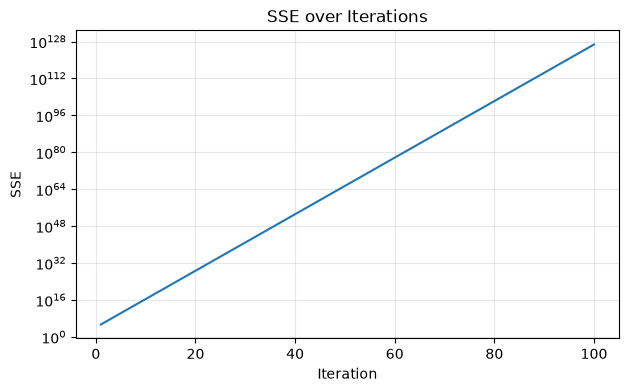

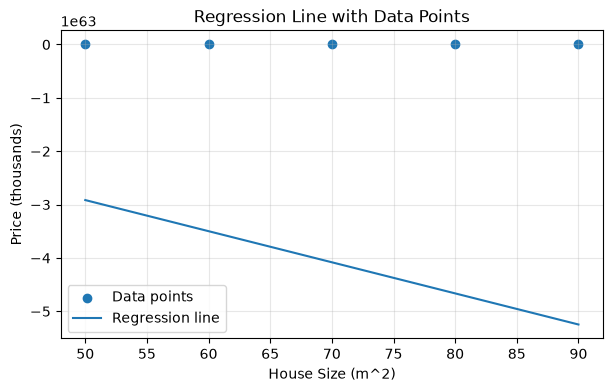

In [5]:
model.plot_training()

### Why does SSE decrease over time?

When the learning rate is suitable, Gradient Descent updates `theta_0` and `theta_1` in the direction that reduces prediction error, so SSE gets smaller over the iterations. In this run, SSE grows because the required learning rate is too large for the current data scale.

### What does convergence mean?

Convergence means the parameter updates become very small and the error stops changing significantly because the algorithm is close to the minimum of the loss function.

## 6. Experimentation with Learning Rate

In [6]:
large_lr_model = LinearRegressionGD(learning_rate=0.005, n_iters=100)
large_lr_model.fit(X, y)

small_lr_model = LinearRegressionGD(learning_rate=0.000001, n_iters=100)
small_lr_model.fit(X, y)

print('Very large learning rate (0.005)')
print(f'Final SSE: {large_lr_model.sse_history[-1]:.6e}')
print('Convergence speed: Does not converge; the error grows quickly.')

print()
print('Very small learning rate (0.000001)')
print(f'Final SSE: {small_lr_model.sse_history[-1]:.6e}')
print('Convergence speed: Very slow; the error decreases but is still far from the minimum after 100 iterations.')

Very large learning rate (0.005)
Final SSE: 2.707240e+280
Convergence speed: Does not converge; the error grows quickly.

Very small learning rate (0.000001)
Final SSE: 8.337329e+04
Convergence speed: Very slow; the error decreases but is still far from the minimum after 100 iterations.


### What happens if the learning rate is too large?

The updates can overshoot the minimum. Instead of getting closer to the best values of `theta_0` and `theta_1`, the parameters move farther away, causing SSE to increase and the model to diverge.